In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

병원에서는 예약한 환자들이 오지 않아 진료가 원활하게 이루어지지 않는 일이 발생된다. 예약하고 오지 않는 환자들의 특징을 파악해서 no show 발생률을 줄일 수 있는 아이디어를 제시하자.

# 병원 노쇼 환자 데이터 분석하기

## 데이터 읽고 확인하기

각 컬럼의 의미  
`PatientId`: 환자 id  
`AppointmentID`: 예약 id  
`Gender`: 성별  
`ScheduledDay`: 예약일  
`AppointmentDay`: 실제 방문일  
`Age`: 나이  
`Neighbourhood`: 병원 위치  
`SMS_received`: 알림 메시지 수락 여부  
`No-show`: 노쇼 여부


In [2]:
# 데이터 읽기
df = pd.read_csv('./data/medical.csv')
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,1,No
110523,3.600000e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,1,No
110524,1.560000e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,1,No
110525,9.210000e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,1,No


In [3]:
# 데이터 컬럼명 확인
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'SMS_received', 'No-show'],
      dtype='str')

In [4]:
# 전반적인 데이터 정보 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   SMS_received    110527 non-null  int64  
 8   No-show         110527 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 7.6 MB


## 결측치 확인

In [8]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
SMS_received      0
No-show           0
dtype: int64

isnull() 메소드는 데이터프레임 내의 모든 원소를 검사하여 각 값이 결측치인지 확인해서 결측치면 True, 결측치가 아니면 False를 리턴한다.  
any() 메소드는 특정 축(axis 속성)을 따라 하나 이상의 True가 존재하는지 확인해서 존재하면 True, 존재하지 않으면 False를 리턴한다.  
any() 메소드 axis 속성의 기본값은 0이며 행 방향 중 하나라도 True가 있는 검사하고 1로 지정하면 열 방향 중 하나라도 True가 있는지 검사한다.

In [11]:
# 열 방향 중 하나라도 True(결측치)가 있는지 검사한다.
df.isnull().any() # any(axis=0)

PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
SMS_received      False
No-show           False
dtype: bool

In [12]:
# 행 방향 중 하나라도 True(결측치)가 있는지 검사한다.
df.isnull().any(axis=1)

0         False
1         False
2         False
3         False
4         False
          ...  
110522    False
110523    False
110524    False
110525    False
110526    False
Length: 110527, dtype: bool

## 통계량을 이용하여 이상치 제거

In [13]:
# 통계량 확인
df.describe()

,PatientId,AppointmentID,Age,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000
mean,1.474961e+14,5.675305e+06,37.088874,0.321026
std,2.560943e+14,7.129575e+04,23.110205,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000
25%,4.170000e+12,5.640286e+06,18.000000,0.000000
50%,3.170000e+13,5.680573e+06,37.000000,0.000000
75%,9.440000e+13,5.725524e+06,55.000000,1.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000


In [15]:
# 나이가 0이상인 값으로만 추출하여 이상치 제거
# df[df.Age < 0]
df = df[df.Age >= 0]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,1,No
110523,3.600000e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,1,No
110524,1.560000e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,1,No
110525,9.210000e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,1,No


## 데이터 타입 변환

In [18]:
# 문자열 데이터인 No-show 열을 'Yes'는 1로 'No'는 0으로 수치형 데이터로 변환한다.
# map() 메소드의 인수에 딕셔너리 형태로 {수정전내용: 수정후내용, ...}와 같이 넘겨서 일괄 수정할 수 있다.
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})
df['No-show'].value_counts()

No-show
0    88207
1    22319
Name: count, dtype: int64

In [20]:
# 문자열 데이터인 ScheduledDay 열과 AppointmentDay 열을 날짜/시간형 데이터로 변환한다.
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df.info()

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   SMS_received    110526 non-null  int64              
 8   No-show         110526 non-null  int64              
dtypes: datetime64[us, UTC](2), float64(1), int64(4), str(2)
memory usage: 8.4 MB


## 파생 변수 추가

In [37]:
# 'waiting_day'라는 환자가 예약하고 병원 방문까지 기다리는 기간을 추가한다.
# 시리즈에 날짜/시간 관련 기능을 실행하려면 dt를 사용해서 일시적으로 시리즈를 날짜/시간 관련 기능을 사용할 수 있는 상태로 변환해야 한다.
df['waiting_day'] = df['AppointmentDay'].dt.day_of_year - df['ScheduledDay'].dt.day_of_year
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
...,...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,1,0,35
110523,3.600000e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,1,0,35
110524,1.560000e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,1,0,41
110525,9.210000e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,1,0,41


In [38]:
# 새로 추가한 컬럼(waiting_day)에 이상치 확인
df.describe()

,PatientId,AppointmentID,Age,SMS_received,No-show,waiting_day
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474932e+14,5.675304e+06,37.089219,0.321029,0.201934,9.979046
std,2.560937e+14,7.129544e+04,23.110026,0.466874,0.401445,15.607516
min,3.920000e+04,5.030230e+06,0.000000,0.000000,0.000000,-223.000000
25%,4.170000e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000
50%,3.170000e+13,5.680572e+06,37.000000,0.000000,0.000000,4.000000
75%,9.440000e+13,5.725523e+06,55.000000,1.000000,0.000000,15.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000,1.000000,146.000000


In [41]:
# waiting_day가 0이상인 값으로만 추출하여 이상치 제거
# df[df['waiting_day'] < 0]
df = df[df['waiting_day'] >= 0]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
...,...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,1,0,35
110523,3.600000e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,1,0,35
110524,1.560000e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,1,0,41
110525,9.210000e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,1,0,41


값을 확인하여 이상치 제거

In [43]:
df.Age.unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99],
      dtype=int64)

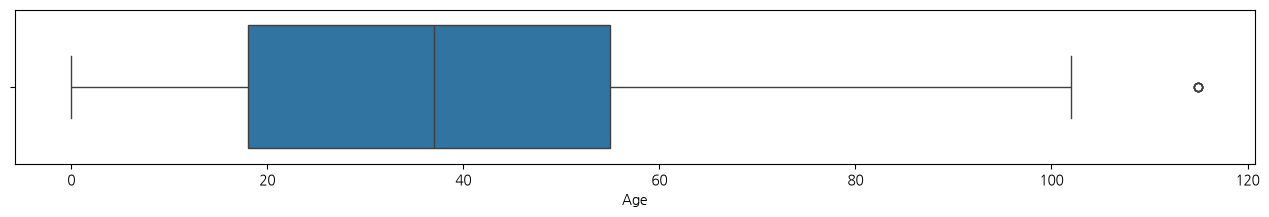

In [44]:
plt.figure(figsize=(16, 2))
sns.boxplot(x=df.Age)
plt.show()

In [46]:
# df[df.Age > 110]
df = df[df.Age <= 110]
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show,waiting_day
0,2.990000e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,0,0
1,5.590000e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
2,4.260000e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0
3,8.680000e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0
4,8.840000e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0
...,...,...,...,...,...,...,...,...,...,...
110522,2.570000e+12,5651768,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,1,0,35
110523,3.600000e+12,5650093,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,1,0,35
110524,1.560000e+13,5630692,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,1,0,41
110525,9.210000e+13,5630323,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,1,0,41


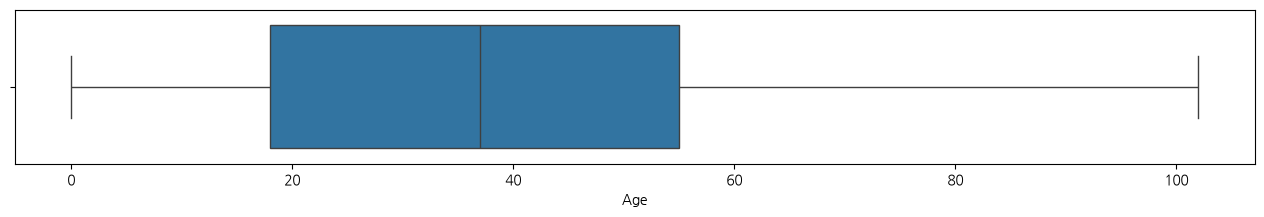

In [47]:
plt.figure(figsize=(16, 2))
sns.boxplot(x=df.Age)
plt.show()

당일 예약 건수 중 노쇼 비율

In [68]:
# 당일 예약 노쇼 건수 / 당일 예약 건수
a = df[df['waiting_day'] == 0]['waiting_day'].value_counts()
b = df[(df['waiting_day'] == 0) & (df['No-show'] == 1)]['waiting_day'].value_counts()
print('당일 예약 건수: {:,d}건, 당일 예약 노쇼 건수: {:,d}건'.format(a.values[0], b.values[0]))
print('당일 예약 건수 중 노쇼 비율: {:6.2%}'.format((b / a).values[0]))

당일 예약 건수: 38,561건, 당일 예약 노쇼 건수: 1,792건
당일 예약 건수 중 노쇼 비율:  4.65%


환자가 예약하고 병원 방문까지 기다리는 기간에 따른 노쇼 여부 파악

In [69]:
# 노쇼 여부에 따른 데이터 분할
no_show = df[df['No-show'] == 1] # 노쇼
show = df[df['No-show'] == 0] # 쇼

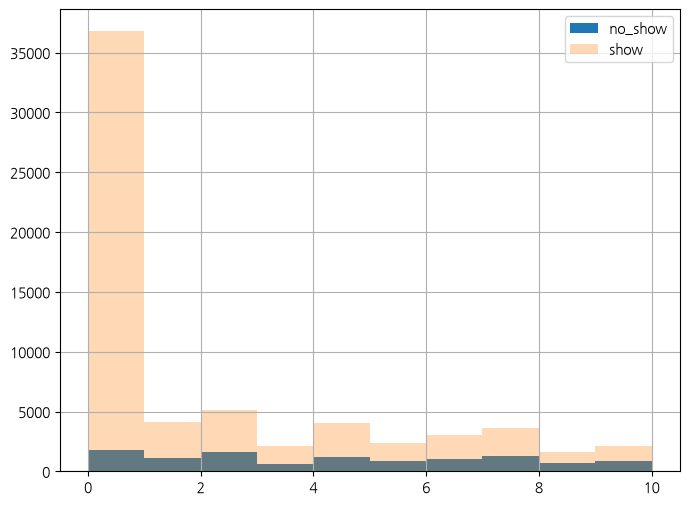

In [79]:
plt.figure(figsize=(8, 6))
no_show[no_show['waiting_day'] <= 10]['waiting_day'].hist(label='no_show')
show[show['waiting_day'] <= 10]['waiting_day'].hist(label='show', alpha=0.3)
plt.legend()
plt.show()

예약일(ScheduledDay)에 따른 노쇼 여부 파악

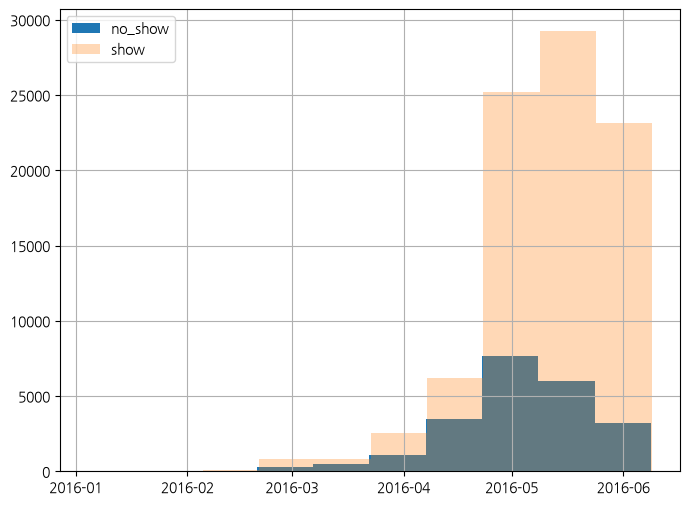

In [80]:
plt.figure(figsize=(8, 6))
no_show['ScheduledDay'].hist(label='no_show')
show['ScheduledDay'].hist(label='show', alpha=0.3)
plt.legend()
plt.show()

실제 방문일(AppointmentDay)에 따른 노쇼 여부 파악

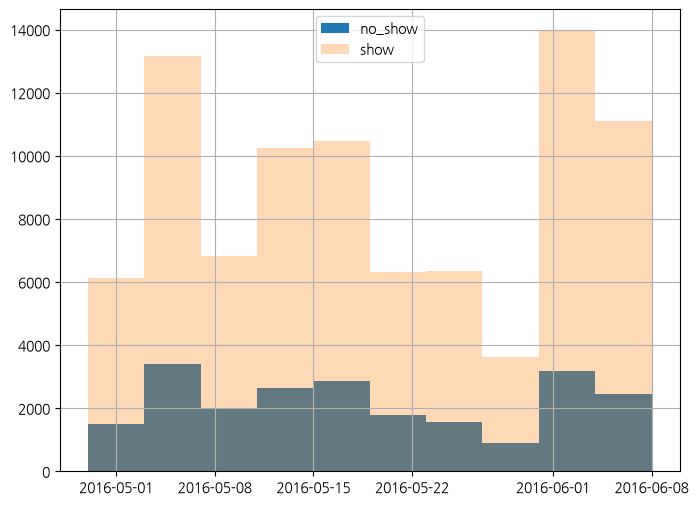

In [81]:
plt.figure(figsize=(8, 6))
no_show['AppointmentDay'].hist(label='no_show')
show['AppointmentDay'].hist(label='show', alpha=0.3)
plt.legend()
plt.show()

방문 횟수 상위 10명 환자 확인하기

In [83]:
df.PatientId.value_counts().head(10)

PatientId
8.220000e+14    141
3.350000e+13    127
7.580000e+13    124
8.190000e+13    123
2.690000e+13    117
6.540000e+13    112
6.680000e+13    106
1.450000e+13    104
8.530000e+14    102
8.920000e+13    101
Name: count, dtype: int64

방문 횟수 상위 500명 환자 시각화

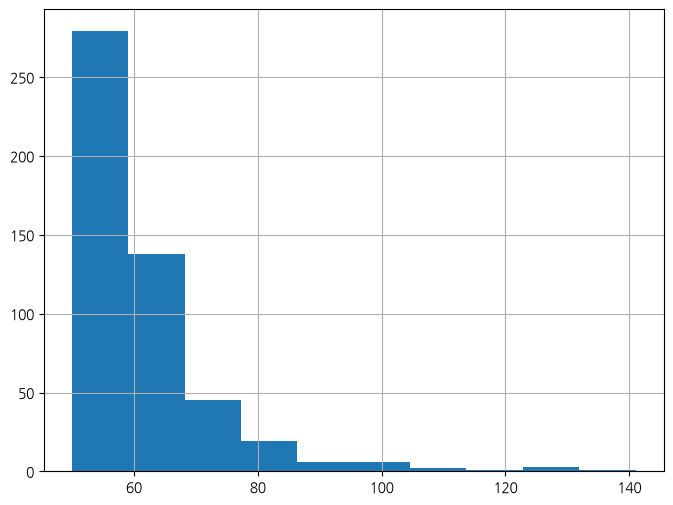

In [87]:
plt.figure(figsize=(8, 6))
df.PatientId.value_counts().head(500).hist()
plt.show()

환자 별로 기다리는 기간(waiting_day)이 50일 이상에 따른 노쇼 발생 건수 확인

In [93]:
df[(df['waiting_day'] >= 50) & (df['No-show'] == 1)].PatientId.value_counts().head(10)

PatientId
3.380000e+14    6
7.250000e+13    4
7.850000e+13    4
8.340000e+12    4
8.220000e+14    3
4.970000e+12    3
9.150000e+14    3
5.670000e+12    3
8.460000e+12    3
5.290000e+12    3
Name: count, dtype: int64

메시지 수락 여부(SMS_received)와 기다리는 기간(waiting_day)에 따른 노쇼 특성 파악

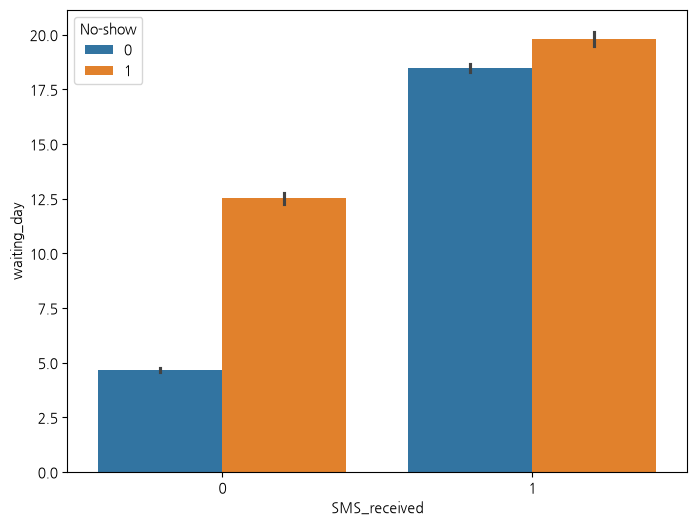

In [95]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='SMS_received', y='waiting_day', hue='No-show')
plt.show()

메시지 수락 여부(SMS_received)와 기다리는 기간(waiting_day)과 노쇼 상관관계 확인

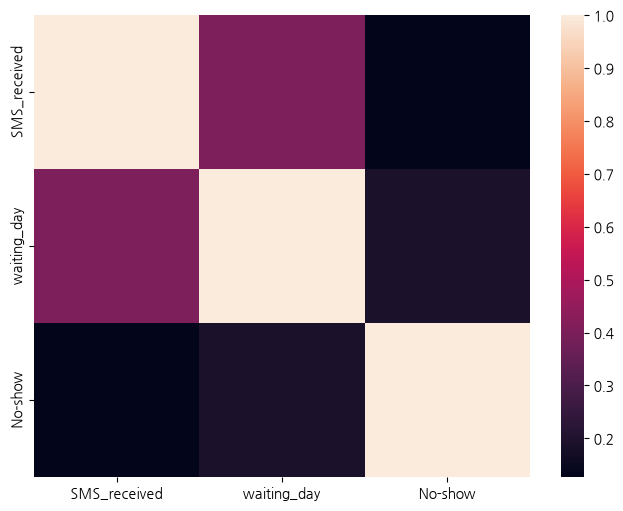

In [96]:
temp = df[['SMS_received', 'waiting_day', 'No-show']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(temp)
plt.show()

얼마나 많은 환자가 예정된 약속에 오지 않았는가?

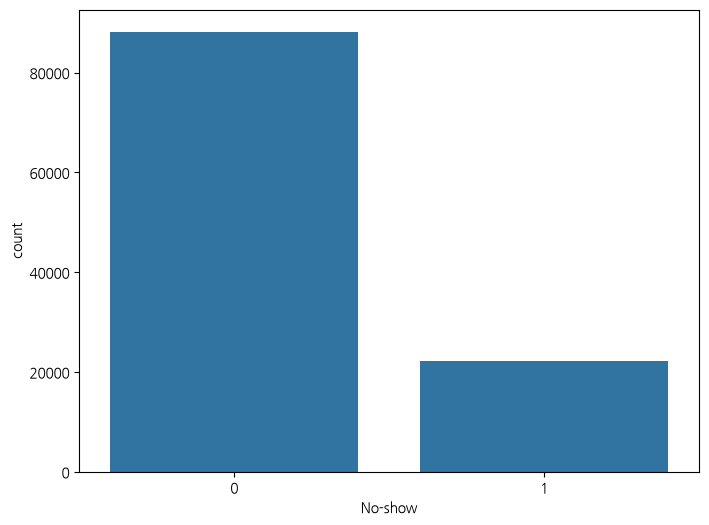

In [97]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='No-show')
plt.show()

성별에 따른 노쇼 여부 차이

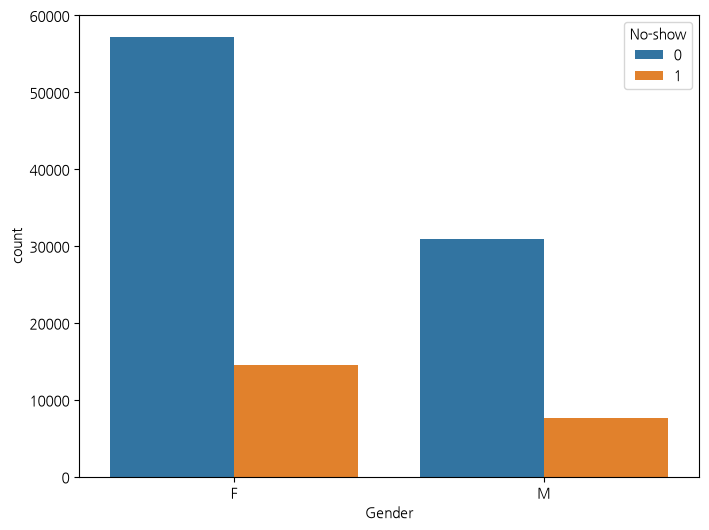

In [99]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', hue='No-show')
plt.show()

메시지 수락 여부에 따른 노쇼 비율 파악

In [112]:
a = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 1)]) # 메시지를 수락한 노쇼 건수
b = len(df[(df['SMS_received'] == 0) & (df['No-show'] == 0)]) # 메시지를 수락한 뇨 건수
print(f'메시지를 수락한 노쇼 건수: {a}')
print(f'메시지를 수락한 쇼 건수: {b}')
print(f'메시지를 수락했을 때 노쇼 비율: {a / (a + b)}')

c = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 1)]) # 메시지를 수락하지 않은 노쇼 건수
d = len(df[(df['SMS_received'] == 1) & (df['No-show'] == 0)]) # 메시지를 수락하지 않은 뇨 건수
print(f'메시지를 수락하지 않은 노쇼 건수: {c}')
print(f'메시지를 수락하지 않은 쇼 건수: {d}')
print(f'메시지를 수락하지 않았을 때 노쇼 비율: {c / (c + d)}')

메시지를 수락한 노쇼 건수: 12522
메시지를 수락한 쇼 건수: 62494
메시지를 수락했을 때 노쇼 비율: 0.1669243894635811
메시지를 수락하지 않은 노쇼 건수: 9770
메시지를 수락하지 않은 쇼 건수: 25668
메시지를 수락하지 않았을 때 노쇼 비율: 0.2756927591850556


성별에 따른 노쇼 비율 파악

In [119]:
f = len(df[(df['Gender'] == 'F') & (df['No-show'] == 1)]) # 여성 노쇼 인원수
m = len(df[(df['Gender'] == 'M') & (df['No-show'] == 1)]) # 남성 노쇼 인원수
f_tot = len(df[(df['Gender'] == 'F')]) # 여성 전체 인원수
m_tot = len(df[(df['Gender'] == 'M')]) # 남성 전체 인원수

print(f / f_tot)
print(m / m_tot)

0.20306187836068315
0.19951898210406538
